<a href="https://colab.research.google.com/github/2BerbyMarty2/Simulation-and-Stochastic-Analysis-of-Hospital-Emergency-Resources/blob/main/ER_Resource_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages(c("simmer", "simmer.plot", "gridExtra", "dplyr"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(ggplot2)
library(dplyr)
library(tidyverse)
library(simmer)
library(simmer.plot)
library(gridExtra)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
✔ readr     2.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘simmer’


The following objects are masked from ‘package:lubridate’:

    now, rollback


The following object is masked from ‘package:tidyr’:

    separate


The following object is masked from ‘package:dplyr’:

    select



Attaching package: ‘simmer.plot’


The following objects are masked

In [3]:
# Seed for exact mathematical comparison
set.seed(2026)
arrival_rate <- 12 / 60
service_rate <- 1 / 12

# Define the patient trajectory
patient_path <- trajectory("ER_Patient") %>%
  seize("triage_doctor", 1) %>%
  timeout(function() rexp(1, service_rate)) %>%
  release("triage_doctor", 1)

# Build and execute the 3-doctor baseline environment
env_baseline <- simmer("Hospital_ER_Baseline") %>%
  add_resource("triage_doctor", capacity = 3) %>%
  add_generator("patient", patient_path, function() rexp(1, arrival_rate))

env_baseline %>% run(until = 4000)

# Extract and Calculate
results_baseline <- get_mon_arrivals(env_baseline) %>%
  filter(finished == TRUE) %>%
  mutate(waiting_time = end_time - start_time - activity_time,
         patient_id = row_number()) %>%
  head(500)



avg_wait_baseline <- round((mean(results_baseline$waiting_time)),2 )
base_row_no <- nrow(results_baseline)

# Formula: L_q = lambda * W_q
avg_queue_length <- round((arrival_rate * avg_wait_baseline), 2)

cat(paste0(
  "Summary Statistics (3 Doctors):\n",
  " - Average Wait Time: ", avg_wait_baseline, " minutes\n",
  " - Total Patients Evaluated: ", base_row_no, "\n",
  " - Average Queue Length: ", avg_queue_length, " patients\n"
))

simmer environment: Hospital_ER_Baseline | now: 4000 | next: 4000.60084642297
{ Monitor: in memory }
{ Resource: triage_doctor | monitored: TRUE | server status: 3(3) | queue status: 2(Inf) }
{ Source: patient | monitored: 1 | n_generated: 767 }

Summary Statistics (3 Doctors):
 - Average Wait Time: 8.45 minutes
 - Total Patients Evaluated: 500
 - Average Queue Length: 1.69 patients


In [4]:
# Seed for exact mathematical comparison
set.seed(2026)

# Build and execute the 4-doctor alternative environment
env_alt <- simmer("Hospital_ER_Alt") %>%
  add_resource("triage_doctor", capacity = 4) %>%
  add_generator("patient", patient_path, function() rexp(1, arrival_rate))

env_alt %>% run(until = 4000)

# Extract and Calculate
results_alt <- get_mon_arrivals(env_alt) %>%
  filter(finished == TRUE) %>%
  mutate(waiting_time = end_time - start_time - activity_time,
         patient_id = row_number()) %>%
  head(500)



avg_wait_alt <- round((mean(results_alt$waiting_time)), 2)
alt_row_no <- nrow(results_alt)

# Calculate Average Queue Length using Little's Law (L_q = lambda * W_q)
avg_queue_alt <- round((arrival_rate * avg_wait_alt),2)


cat(paste0(
  "Summary Statistics (4 Doctors):\n",
  " - Average Wait Time: ", avg_wait_alt, " minutes\n",
  " - Total Patients Evaluated: ", alt_row_no, "\n",
  " - Average Queue Length: ", avg_queue_alt, " patients\n"
))

simmer environment: Hospital_ER_Alt | now: 4000 | next: 4005.78848130557
{ Monitor: in memory }
{ Resource: triage_doctor | monitored: TRUE | server status: 2(4) | queue status: 0(Inf) }
{ Source: patient | monitored: 1 | n_generated: 772 }

Summary Statistics (4 Doctors):
 - Average Wait Time: 2.38 minutes
 - Total Patients Evaluated: 500
 - Average Queue Length: 0.48 patients


In [5]:
# 1. Histogram for 3 Doctors
hist3 <- ggplot(results_baseline, aes(x = waiting_time)) +
  geom_histogram(binwidth = 2, fill = "#5bc0de", color = "white") +
  geom_vline(xintercept = 10, linetype = "dashed", color = "red", size = 1) +
  labs(title = "Wait Time Distribution (3 Doctors)", x = "Wait Time (min)", y = "Patient Count") +
  theme_minimal()

# 2. Resource Usage for 3 Doctors
max_time3 <- max(results_baseline$end_time)
res3 <- plot(get_mon_resources(env_baseline), metric = "usage", items = "server", steps = TRUE) +
  coord_cartesian(xlim = c(0, max_time3)) +
  labs(title = "Doctor Utilization (3 Doctors)", x = "Simulation Time", y = "Active Doctors") +
  theme_minimal() +
  theme(legend.position = "none")

# 3. Histogram for 4 Doctors
hist4 <- ggplot(results_alt, aes(x = waiting_time)) +
  geom_histogram(binwidth = 2, fill = "#5cb85c", color = "white") +
  geom_vline(xintercept = 10, linetype = "dashed", color = "red", size = 1) +
  labs(title = "Wait Time Distribution (4 Doctors)", x = "Wait Time (min)", y = "Patient Count") +
  theme_minimal()

# 4. Resource Usage for 4 Doctors
max_time4 <- max(results_alt$end_time)
res4 <- plot(get_mon_resources(env_alt), metric = "usage", items = "server", steps = TRUE) +
  coord_cartesian(xlim = c(0, max_time4)) +
  labs(title = "Doctor Utilization (4 Doctors)", x = "Simulation Time", y = "Active Doctors") +
  theme_minimal() +
  theme(legend.position = "none")

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


In [6]:
# 2. Waiting Time Plots (Patients)
plot_wait3 <- ggplot(results_baseline, aes(x = start_time, y = waiting_time)) +
  geom_point(alpha = 0.5, color = "blue") +
  geom_hline(yintercept = 10, linetype = "dashed", color = "red", linewidth = 1) +
  labs(title = "Patient Waiting Times: 3 Doctors", x = "Simulation Time (mins)", y = "Wait Time (mins)") +
  theme_minimal()

plot_wait4 <- ggplot(results_alt, aes(x = start_time, y = waiting_time)) +
  geom_point(alpha = 0.5, color = "darkgreen") +
  geom_hline(yintercept = 10, linetype = "dashed", color = "red", linewidth = 1) +
  labs(title = "Patient Waiting Times: 4 Doctors", x = "Simulation Time (mins)", y = "Wait Time (mins)") +
  theme_minimal()

In [7]:
# 1. Create simple vectors
Metric <- c("Avg Waiting Time (min)", "Avg Queue Length", "Total Patients", "Target Met")
Baseline <- c(round(avg_wait_baseline, 2), round(avg_queue_length, 2), nrow(results_baseline), "YES")
Alternative <- c(round(avg_wait_alt, 2), round(avg_queue_alt, 2), nrow(results_alt), "YES")

# 2. Combine into a simple data frame
simple_table <- data.frame(Metric, Baseline, Alternative)

In [8]:
simple_table

Metric,Baseline,Alternative
<chr>,<chr>,<chr>
Avg Waiting Time (min),8.45,2.38
Avg Queue Length,1.69,0.48
Total Patients,500,500
Target Met,YES,YES


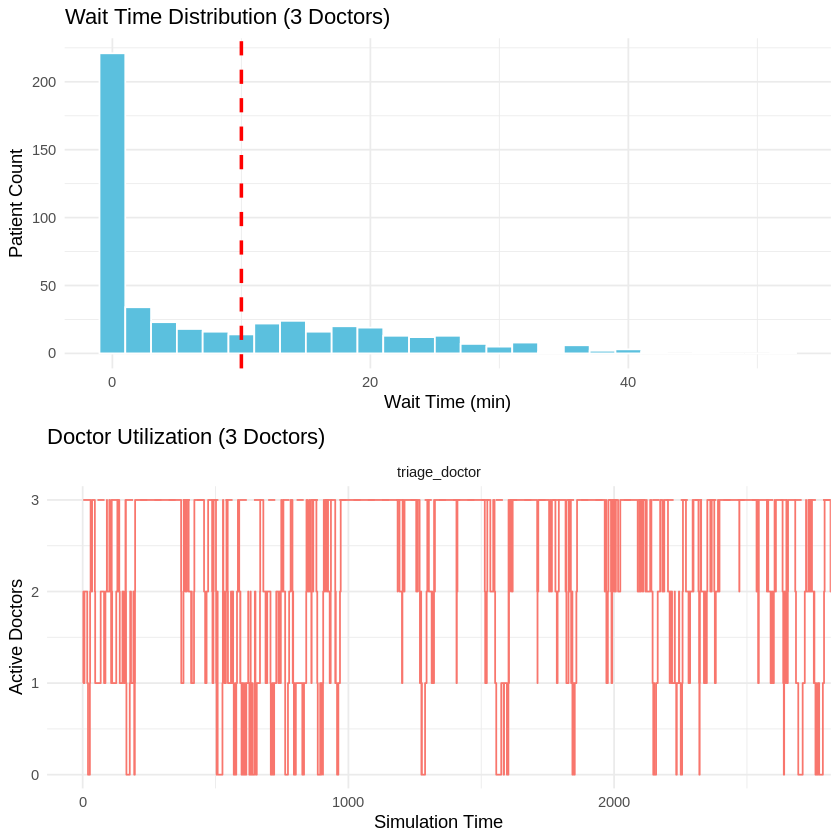

In [9]:
# Arrange vertically for 3 Doctors
grid.arrange(hist3, res3, nrow = 2)

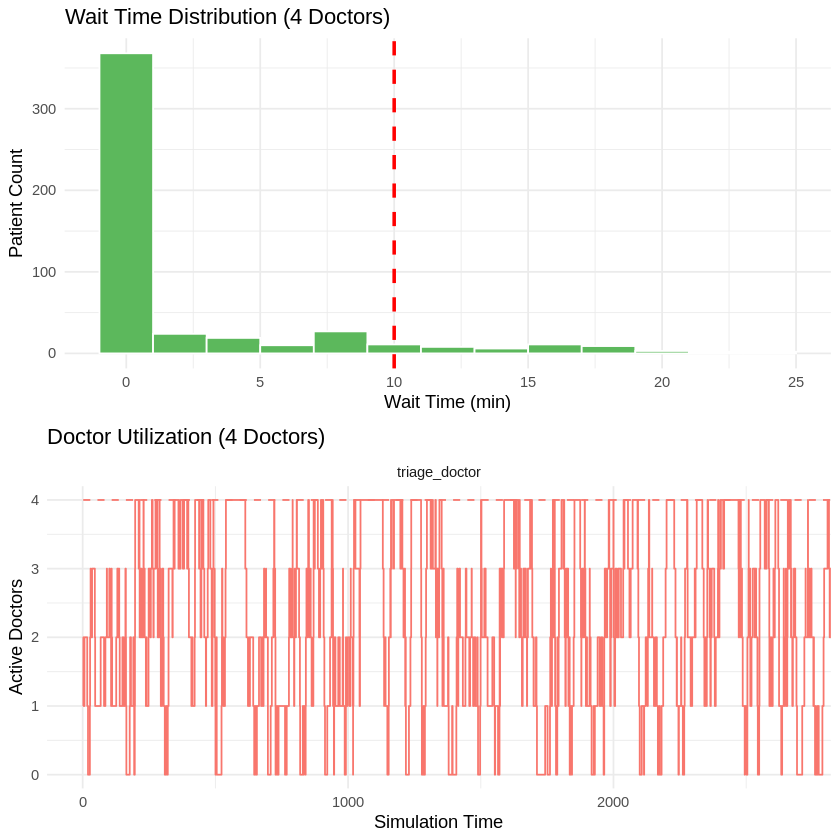

In [10]:
# Arrange vertically for 4 Doctors
grid.arrange(hist4, res4, nrow = 2)

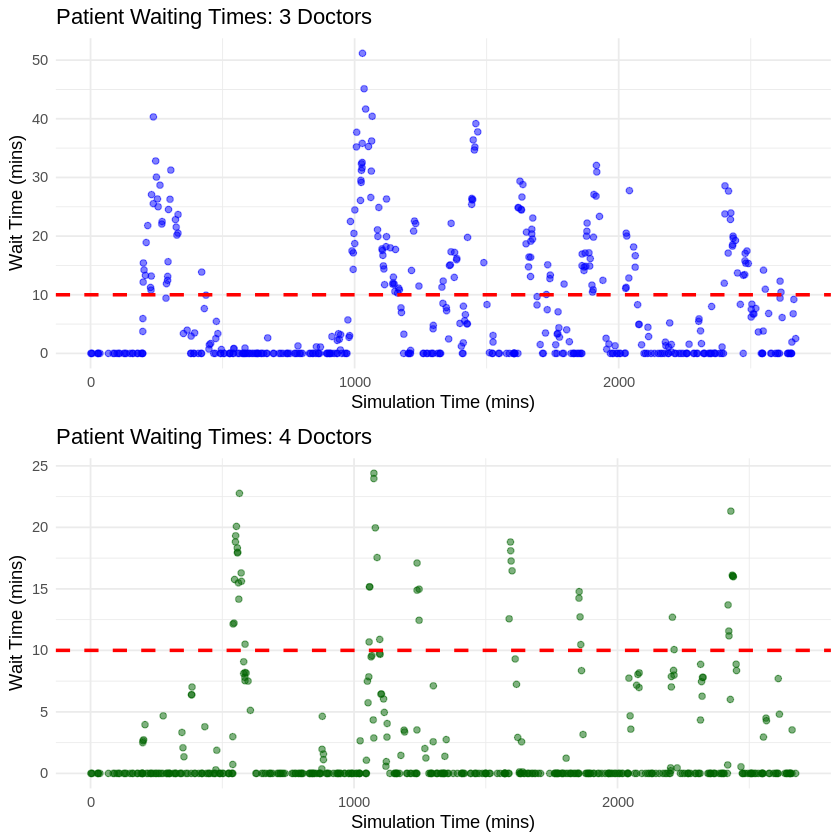

In [11]:
grid.arrange(plot_wait3, plot_wait4, nrow = 2)